In [935]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import place_poles

### Exercise 1. Linear State Observers

#### Item a.

Considering the simulation model below, implement a state observer to estimate the system's velocity from position measurements and compare the results,  qualitatively and quantitatively, with the position difference estimator and the acceleration integration estimator for different values for the measurement noise variance and the input uncertainty variance, but disregarding (setting to zero) the input uncertainty bias.

#### Item b.

Repeat the procedure from Item a. but now considering the effects of input uncertainty bias. Adapt the state observer design to compensate for the input uncertainty bias.

#### Item c.

Design a linear Kalman filter to estimate the system's velocity from position measurements and compare the results, qualitatively and quantitatively, with the linear state observer designed in Item a. for different values for the measurement noise variance and the input uncertainty variance, but disregarding (setting to zero) the input uncertainty bias.


In [936]:
class Simulation_Result:
    def __init__(self):
        self.states = None
        self.measurements = None
        self.estimated_states = None
        self.inputs = None
        self.inputs_with_uncertainty = None

In [937]:
class Acceleration_Integration_Estimation:
    def __init__(self, time_step):

        self.velocity_estimate = 0.0
        self.time_step = time_step

        return

    def estimate_states(self, measurement, input):

        self.velocity_estimate = self.velocity_estimate + self.time_step*input

        return np.array([measurement,self.velocity_estimate])

In [938]:
class Position_Difference_Estimation:
    def __init__(self, time_step):

        self.last_measurement = 0.0
        self.time_step = time_step

        return

    def estimate_states(self, measurement, input):

        velocity_estimate = (measurement - self.last_measurement)/self.time_step

        self.last_measurement = measurement

        return np.array([measurement,velocity_estimate])

In [939]:
class Simple_Mechanical_System_State_Observer:
    def __init__(self, time_step):
        # Implement
        pass

    def design_observer_gain(self, A, C, desired_poles):
        return place_poles(A.T, C.T, desired_poles).gain_matrix.T

    def estimate_states(self, measurement, input):
        # implement
        pass

In [940]:
class Simple_Mechanical_System_Kalman_Filter:
    def __init__(self, time_step, measurement_variance, input_uncertainty_variance):
        #implement
        pass

    def estimate_states(self, measurement, input):
        #implement
        pass

In [941]:
class Simple_Mechanical_System:
    def __init__(self, time_step, measurement_noise_variance = None, input_uncertainty_variance = None, input_uncertainty_bias = None):
        self.position_state_index = 0
        self.velocity_state_index = 1
        self.time_step = time_step

        self.measurement_noise_variance = measurement_noise_variance

        self.input_uncertainty_variance = input_uncertainty_variance
        self.input_uncertainty_bias = input_uncertainty_bias

        self.input_variance = 0.5

        if (None == self.input_uncertainty_variance and None != self.input_uncertainty_bias):
            raise Exception("Input uncertainty model requires measurement noise variance specification")

        if (None == self.input_uncertainty_bias):
            self.input_uncertainty_bias = 0.0

        return

    def simulate_step(self, state, input):
        next_state = np.zeros(state.size)

        next_state[self.position_state_index] = state[self.position_state_index] + self.time_step*state[self.velocity_state_index]
        next_state[self.velocity_state_index] = state[self.velocity_state_index] + self.time_step*input

        return next_state

    def measure(self, state):

        measurement = state[self.position_state_index]

        if (None != self.measurement_noise_variance):
            measurement = measurement + np.random.normal(0.0,np.sqrt(self.measurement_noise_variance))

        return measurement

    def add_uncertainty_to_input(self, input):
        uncertain_input = input

        if (None != self.input_uncertainty_variance and None != self.input_uncertainty_bias):
            uncertain_input = uncertain_input + np.random.normal(np.sqrt(self.input_uncertainty_bias),np.sqrt(self.input_uncertainty_variance))

        return uncertain_input

    def simulate(self, simulation_time_s, estimator = None):

        np.random.seed(14533)

        simulation_result = Simulation_Result()

        simulation_steps = math.ceil(simulation_time_s/self.time_step)

        simulation_result.states = np.zeros((simulation_steps,2))
        simulation_result.measurements = np.zeros(simulation_steps)

        simulation_result.inputs = np.zeros(simulation_steps)
        simulation_result.inputs_with_uncertainty = np.zeros(simulation_steps)

        if None != estimator:
            simulation_result.estimated_states = np.zeros((simulation_steps,2))

        for i in range(1,simulation_steps):

            simulation_result.states[i,:] = self.simulate_step(simulation_result.states[i-1,:], simulation_result.inputs_with_uncertainty[i-1])

            simulation_result.measurements[i] = self.measure(simulation_result.states[i,:])

            if (None != estimator):
                simulation_result.estimated_states[i,:] = estimator.estimate_states(simulation_result.measurements[i], simulation_result.inputs[i-1])

            alpha = 0.1

            simulation_result.inputs[i] = (alpha)*simulation_result.inputs[i-1] + (1-alpha)*self.time_step*np.random.normal(0,self.input_variance)
            simulation_result.inputs_with_uncertainty[i] = self.add_uncertainty_to_input(simulation_result.inputs[i])

        return simulation_result

In [942]:
# Change the parameters below to use the simulation

simulation_time = 10
time_step = 0.05

measurement_noise_variance=0.5
input_uncertainty_variance=0.5
input_uncertainty_bias = 0.5

system = Simple_Mechanical_System(time_step, measurement_noise_variance=measurement_noise_variance, input_uncertainty_variance=input_uncertainty_variance, input_uncertainty_bias=input_uncertainty_bias)
simulation_result = system.simulate(simulation_time)

# For different estimators just use:
# simulation_result_acceleration_estimator = system.simulate(simulation_time, Acceleration_Integration_Estimation(time_step))
# simulation_result_position_estimator = system.simulate(simulation_time, Position_Difference_Estimation(time_step))
# simulation_result_observer_estimator = system.simulate(simulation_time, Simple_Mechanical_System_State_Observer(time_step))
# simulation_result_kalman_filter_estimator = system.simulate(simulation_time, Simple_Mechanical_System_Kalman_Filter(time_step, measurement_noise_variance, input_uncertainty_variance))

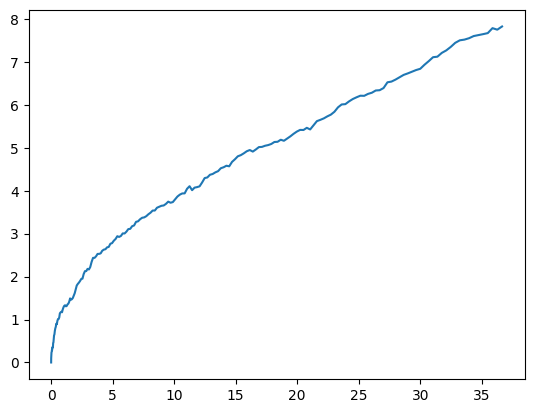

In [943]:
# Access the simulation states by:
plt.plot(simulation_result.states[:,system.position_state_index], simulation_result.states[:,system.velocity_state_index])

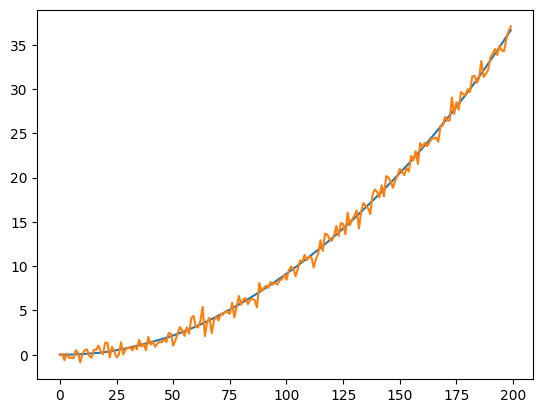

In [944]:
# Access the simulation measurements by:
plt.plot(simulation_result.states[:,system.position_state_index])
plt.plot(simulation_result.measurements)

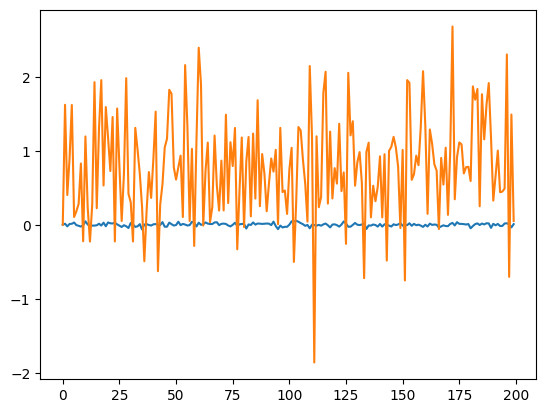

In [945]:
# Access the simulation inputs by:
plt.plot(simulation_result.inputs)
plt.plot(simulation_result.inputs_with_uncertainty)

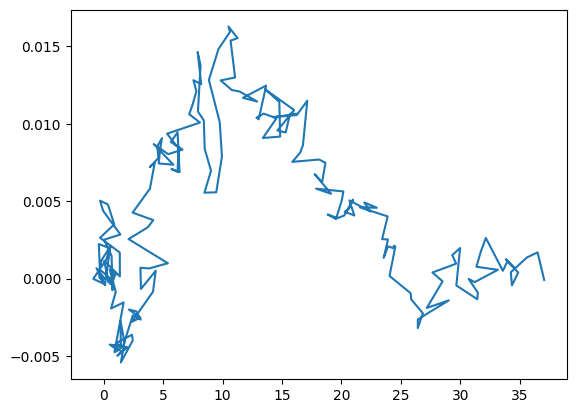

In [947]:
# Access the simulation estimates by:
simulation_result_acceleration_estimator = system.simulate(simulation_time, Acceleration_Integration_Estimation(time_step))
plt.plot(simulation_result_acceleration_estimator.estimated_states[:,system.position_state_index], simulation_result_acceleration_estimator.estimated_states[:,system.velocity_state_index])

### Exercise 2. Nonlinear Kalman Filters

#### Item a.

Considering the simulation model below, implement an extended Kalman Filter and an Unscented Kalman filter to estimate the system's state from position (GNSS), acceleration and angular velocity measurements (IMU) and compare the results, qualitatively and quantitatively, for different values for the measurement noise variance, the input uncertainty variance and GNSS update period (as a multiple of the time step, considering that the time step is equal to the IMU sampling period), but disregarding (setting to zero) the input uncertainty bias.

#### Item b.

Repeat the procedure from Item a. but now considering the effects of input uncertainty bias. Adapt the Kalman Filters to compensate for the input uncertainty bias.


In [ ]:
class Vehicle_Extended_Kalman_Filter:
    def __init__(self, model, initial_state, initial_covariance):
        # implement

        # The simulation model (Vehicle_Model) can be used to get parameters and integrate the system dynamics

        self.x_hat = initial_state
        pass

    def predict(self, u):
        # implement
        pass

    def update(self, z):
        # implement
        pass

    def estimate_states(self, measurements, inputs, update = False):
        self.predict(inputs)

        if update:
         self.update(measurements)

        return self.x_hat

In [ ]:
class Vehicle_Unscented_Kalman_Filter:
    def __init__(self, model, initial_state, initial_covariance):
        # implement

        # The simulation model (Vehicle_Model) can be used to get parameters and integrate the system dynamics

        self.x_hat = initial_state
        pass

    def predict(self, u):
        # implement
        pass

    def update(self, z):
        # implement
        pass

    def estimate_states(self, measurements, inputs, update = False):
        self.predict(inputs)

        if update:
         self.update(measurements)

        return self.x_hat

In [948]:
class Vehicle_Model:
    def __init__(self, time_step, update_period = 10, measurement_noise_covariance_matrix = None, input_uncertainty_covariance_matrix = None, input_uncertainty_bias_vector = None):
        self.x_index = 0
        self.y_index = 1
        self.yaw_index = 2
        self.velocity_x_index = 3
        self.velocity_y_index = 4

        self.acceleration_x_index = 0
        self.acceleration_y_index = 1
        self.angular_velocity_index = 2
        self.time_step = time_step

        self.measurement_noise_covariance_matrix = measurement_noise_covariance_matrix

        self.input_uncertainty_covariance_matrix = input_uncertainty_covariance_matrix
        self.input_uncertainty_bias_vector = input_uncertainty_bias_vector

        self.update_period = update_period

        if None == self.input_uncertainty_covariance_matrix.any() and None != self.input_uncertainty_bias_vector.any():
            raise Exception("Input uncertainty model requires measurement noise variance specification")

        if None == self.input_uncertainty_bias_vector.any():
            self.input_uncertainty_bias_vector = np.zeros(3)

        self.measurement_matrix = np.array([[1, 0, 0, 0, 0], [0, 1, 0, 0, 0]])

        return

    def simulate_step(self, state, input):
        next_state = np.zeros(state.size)

        next_state[self.x_index] = state[self.x_index] + self.time_step*(state[self.velocity_x_index]*np.cos(state[self.yaw_index]) - state[self.velocity_y_index]*np.sin(state[self.yaw_index]) )
        next_state[self.y_index] = state[self.y_index] + self.time_step*(state[self.velocity_x_index]*np.sin(state[self.yaw_index]) + state[self.velocity_y_index]*np.cos(state[self.yaw_index]) )
        next_state[self.yaw_index] = state[self.yaw_index] + self.time_step*(input[self.angular_velocity_index])
        next_state[self.velocity_x_index] = state[self.velocity_x_index] + self.time_step*(state[self.velocity_y_index]*input[self.angular_velocity_index] + input[self.acceleration_x_index])
        next_state[self.velocity_y_index] = state[self.velocity_y_index] + self.time_step*(-state[self.velocity_x_index]*input[self.angular_velocity_index] + input[self.acceleration_y_index])

        return next_state

    def measure(self, state):

        measurement = self.measurement_matrix@state

        if None != self.measurement_noise_covariance_matrix.any():
            measurement = measurement + np.random.multivariate_normal(np.zeros(measurement.size),self.measurement_noise_covariance_matrix)

        return measurement

    def add_uncertainty_to_input(self, input):
        uncertain_input = input

        if None != self.input_uncertainty_covariance_matrix.any() and None != self.input_uncertainty_bias_vector.any():
            uncertain_input = uncertain_input + np.random.multivariate_normal(self.input_uncertainty_bias_vector,self.input_uncertainty_covariance_matrix)

        return uncertain_input

    def simulate(self, simulation_time_s, estimator = None):

        np.random.seed(14533)

        simulation_result = Simulation_Result()

        simulation_steps = math.ceil(simulation_time_s/self.time_step)

        simulation_result.states = np.zeros((simulation_steps,5))
        simulation_result.measurements = np.zeros((simulation_steps,2))

        simulation_result.inputs = np.zeros((simulation_steps,3))
        simulation_result.inputs_with_uncertainty = np.zeros((simulation_steps,3))

        if None != estimator:
            simulation_result.estimated_states = np.zeros((simulation_steps,5))

        for i in range(1,simulation_steps):

            simulation_result.states[i,:] = self.simulate_step(simulation_result.states[i-1,:], simulation_result.inputs_with_uncertainty[i-1,:])

            simulation_result.measurements[i:,] = self.measure(simulation_result.states[i,:])

            update = i % self.update_period == 0

            if (None != estimator):
                simulation_result.estimated_states[i,:] = estimator.estimate_states(simulation_result.measurements[i,:], simulation_result.inputs[i-1,:], True)

            simulation_result.inputs[i, self.acceleration_x_index] = 0.75*np.sin(0.08*i*time_step)*np.exp(-0.03*i*time_step)
            simulation_result.inputs[i, self.angular_velocity_index] = (0.05*np.sin(0.05*i*time_step) + 0.001*np.sin(0.5*i*time_step))*np.exp(-0.03*i*time_step)
            simulation_result.inputs[i, self.acceleration_y_index] = 0.1*simulation_result.inputs[i-1, self.acceleration_y_index] +  0.9*simulation_result.states[i,self.velocity_x_index]* simulation_result.inputs[i, self.angular_velocity_index]

            simulation_result.inputs_with_uncertainty[i,:] = self.add_uncertainty_to_input(simulation_result.inputs[i,:])

        return simulation_result

In [957]:
# Change the parameters below to use the simulation

simulation_time = 50
time_step = 0.01
update_period = 10

system = Vehicle_Model(time_step, update_period=update_period, measurement_noise_covariance_matrix=np.diag(np.array([25e-1, 25e-1])), input_uncertainty_covariance_matrix=np.diag(np.array([5e-2, 2e-2, 1e-3])), input_uncertainty_bias_vector=np.array([0.00025, 0.00025, 0.00005]))

simulation_result = system.simulate(simulation_time);

# For different estimators just use:
# simulation_result = system.simulate(simulation_time, Vehicle_Extended_Kalman_Filter(system, np.zeros(5), 0.001*np.eye(5)));
# simulation_result = system.simulate(simulation_time, Vehicle_Unscented_Kalman_Filter(system, np.zeros(5), 0.001*np.eye(5)));

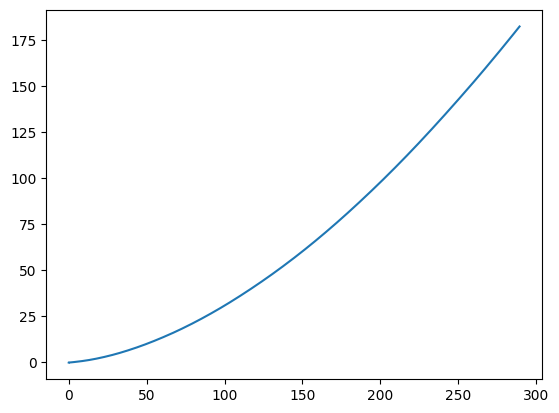

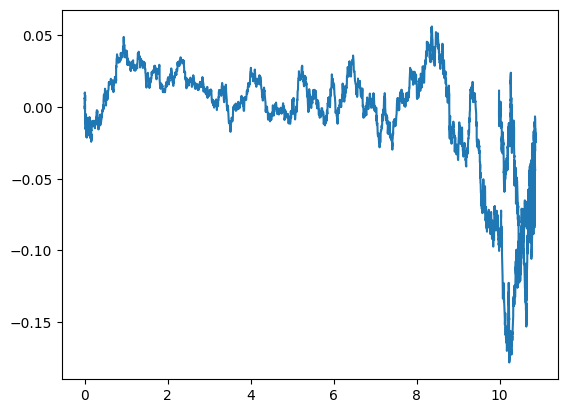

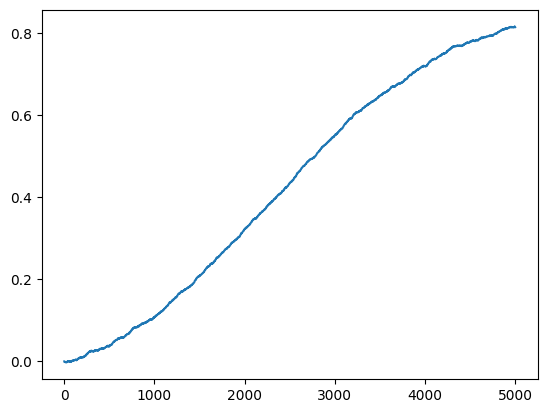

In [959]:
# Access the simulation states by:
plt.plot(simulation_result.states[:,system.x_index], simulation_result.states[:,system.y_index])
plt.show()

plt.plot(simulation_result.states[:,system.velocity_x_index], simulation_result.states[:,system.velocity_y_index])
plt.show()

plt.plot(simulation_result.states[:,system.yaw_index])
plt.show()

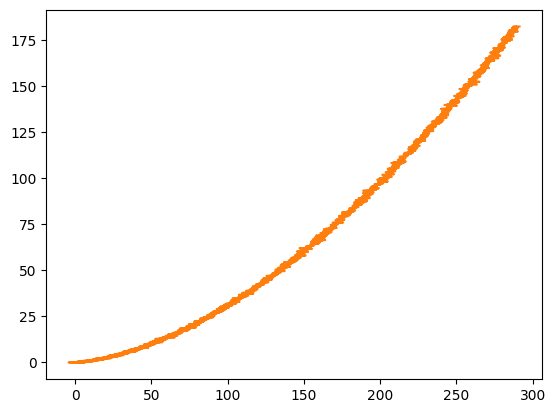

In [960]:
# Access the simulation measurements by:
plt.plot(simulation_result.states[:,system.x_index], simulation_result.states[:,system.y_index])
plt.plot(simulation_result.measurements[:,system.x_index], simulation_result.states[:,system.y_index])
plt.show()

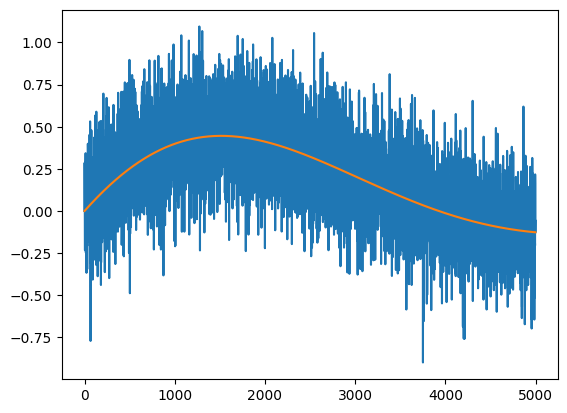

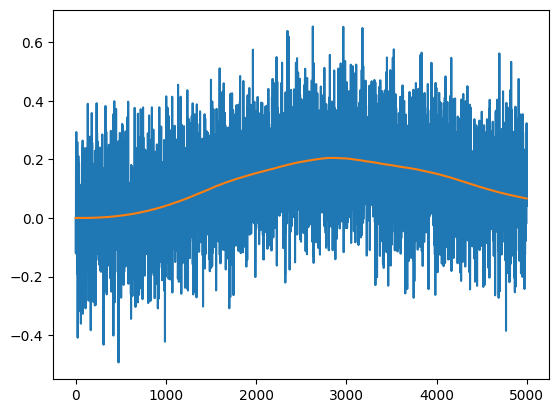

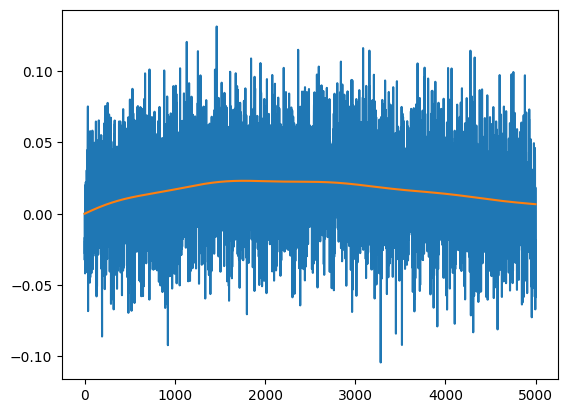

In [965]:
# Access the simulation inputs by:
plt.plot(simulation_result.inputs_with_uncertainty[:,system.acceleration_x_index])
plt.plot(simulation_result.inputs[:,system.acceleration_x_index])
plt.show()

plt.plot(simulation_result.inputs_with_uncertainty[:,system.acceleration_y_index])
plt.plot(simulation_result.inputs[:,system.acceleration_y_index])
plt.show()

plt.plot(simulation_result.inputs_with_uncertainty[:,system.angular_velocity_index])
plt.plot(simulation_result.inputs[:,system.angular_velocity_index])
plt.show()

In [ ]:
# Access the simulation state estimates by:
# Access the simulation states by:
plt.plot(simulation_result.estimated_states[:,system.x_index], simulation_result.estimated_states[:,system.y_index])
plt.plot(simulation_result.states[:,system.x_index], simulation_result.states[:,system.y_index])
plt.show()

plt.plot(simulation_result.estimated_states[:,system.velocity_x_index], simulation_result.estimated_states[:,system.velocity_y_index])
plt.plot(simulation_result.states[:,system.velocity_x_index], simulation_result.states[:,system.velocity_y_index])
plt.show()

plt.plot(simulation_result.estimated_states[:,system.yaw_index])
plt.plot(simulation_result.states[:,system.yaw_index])
plt.show()